# LeWorldModel (LeWM)

**Goal:** run a *real forward inference* with the pretrained **LeWM PushT** checkpoint from the official project, without training a model and without downloading the full PushT dataset.

Repository: https://github.com/lucas-maes/le-wm  
Pretrained checkpoint: https://huggingface.co/quentinll/lewm-pusht  
Project page: https://le-wm.github.io/


### What we will actually demonstrate

1. Load the official LeWM architecture and pretrained PushT weights.
2. Encode an image history into latent states.
3. Encode candidate actions.
4. Predict future latent states autoregressively.
5. Encode a goal image.
6. Score candidate futures by their latent distance to the goal.

This is the central inference loop behind latent-space planning with a learned world model.

## 1. Setup

The official `le-wm` repository contains the LeWM/JEPA implementation.  
We clone it directly and install only the dependencies needed for inference.

The notebook deliberately avoids downloading the full PushT training dataset because it is not necessary for demonstrating the model's forward pass.

In [1]:

%%capture
%pip install -q "stable-pretraining==0.1.8" "transformers==4.57.6" \
    "huggingface_hub<1.0" einops scikit-learn

!rm -rf /content/le-wm
!git clone -q --depth 1 https://github.com/lucas-maes/le-wm.git /content/le-wm

In [2]:
import sys
import json
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import transformers
import stable_pretraining as spt

from PIL import Image, ImageSequence
from huggingface_hub import snapshot_download
from sklearn.decomposition import PCA
from torchvision.transforms import v2 as T

sys.path.insert(0, "/content/le-wm")

print("transformers:", transformers.__version__)
print("stable-pretraining:", getattr(spt, "__version__", "0.1.8"))

assert transformers.__version__.startswith("4."), (
    "This checkpoint requires Transformers 4.x. "
    "Restart the Colab runtime and run the notebook from the first cell."
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

transformers: 4.57.6
stable-pretraining: 0.1.8
Device: cuda
GPU: Tesla T4


## 2. What does **inference** mean in LeWM?

Before looking at any tensor, the key distinction is:

```text
TRAINING:
input -> model -> loss -> backpropagation -> weights change

INFERENCE:
input -> pretrained model -> output
                         ^
                         weights stay fixed
```

In this notebook we are doing **inference only**.

For LeWM:

$
x_t = \text{RGB observation at time }t,
\qquad
a_t = \text{action}.
$

The visual encoder transforms an image into a latent representation:

$
z_t = E_\theta(x_t).
$

The predictor then uses recent latent states **plus actions** to predict the next latent:

$
\hat z_{t+1}
=
P_\phi(z_{t-2},z_{t-1},z_t,\;a_{t-2},a_{t-1},a_t).
$

For several future steps, predictions are reused as inputs:

$
\hat z_{t+1}
\rightarrow
\hat z_{t+2}
\rightarrow
\cdots
\rightarrow
\hat z_{t+K}.
$

This is called an **autoregressive latent rollout**.

For goal-conditioned planning, the goal image is encoded once:

$
z_{\text{goal}} = E_\theta(x_{\text{goal}})
$

and a candidate action sequence receives a cost

$
J =
\left\|
\hat z_{t+K}
-
z_{\text{goal}}
\right\|_2^2.
$

A smaller value means that the **predicted final representation** is closer to the goal representation.

> Important: LeWM does not need to decode future RGB frames here. It predicts directly in latent space.

### Tensor-shape cheat sheet — read this before the code

The letters in tensor shapes are just abbreviations:

| Symbol | Meaning | Value in this notebook |
|---|---|---:|
| `B` | batch size | 1 |
| `S` | number of candidate action plans | 6 |
| `T` | time dimension | depends on the tensor |
| `C` | **RGB image channels** | 3 |
| `H_img` | image height | 224 |
| `W_img` | image width | 224 |
| `D` | latent dimension | 192 |
| `A` | packed action dimension | 10 |
| `HISTORY` | context/history frames | 3 |
| `HORIZON` | future steps we imagine | 5 |

## 3. Load the official pretrained PushT checkpoint

The PushT checkpoint used here has:

- image size: **224 × 224**
- latent dimension: **192**
- context/history length: **3 frames**
- model action input dimension: **10**

### Why is the action dimension 10 if PushT is a 2-D control task?

A raw PushT action has two coordinates:

$
a=(x,y).
$

The training pipeline uses a `frameskip` of 5. Therefore five consecutive 2-D actions are packed together:

```text
(x1, y1,
 x2, y2,
 x3, y3,
 x4, y4,
 x5, y5)
```

So:

```text
5 raw actions × 2 coordinates = 10 values
```

The action encoder therefore receives a vector with shape:

```text
(A,) = (10,)
```

In [3]:
# Download checkpoint + build LeWM with the checkpoint-compatible ViT
from jepa import JEPA
from module import ARPredictor, Embedder, MLP

REPO_ID = "quentinll/lewm-pusht"

# Use the official Hugging Face mirror.
model_dir = Path(
    snapshot_download(
        repo_id=REPO_ID,
        allow_patterns=["config.json", "weights.pt"],
    )
)

with open(model_dir / "config.json", "r") as f:
    cfg = json.load(f)

def without_target(d):
    """Remove Hydra metadata such as `_target_` before calling constructors."""
    return {k: v for k, v in d.items() if not str(k).startswith("_")}

# This is the same ViT construction used by the official LeWM loading recipe.
# Transformers MUST remain on 4.x so that its parameter names match weights.pt.
encoder = spt.backbone.utils.vit_hf(
    cfg["encoder"]["size"],
    patch_size=cfg["encoder"]["patch_size"],
    image_size=cfg["encoder"]["image_size"],
    pretrained=False,
    use_mask_token=False,
)

predictor = ARPredictor(**without_target(cfg["predictor"]))
action_encoder = Embedder(**without_target(cfg["action_encoder"]))

projector = MLP(
    input_dim=cfg["projector"]["input_dim"],
    output_dim=cfg["projector"]["output_dim"],
    hidden_dim=cfg["projector"]["hidden_dim"],
    norm_fn=torch.nn.BatchNorm1d,
)

pred_proj = MLP(
    input_dim=cfg["pred_proj"]["input_dim"],
    output_dim=cfg["pred_proj"]["output_dim"],
    hidden_dim=cfg["pred_proj"]["hidden_dim"],
    norm_fn=torch.nn.BatchNorm1d,
)

model = JEPA(
    encoder=encoder,
    predictor=predictor,
    action_encoder=action_encoder,
    projector=projector,
    pred_proj=pred_proj,
)

# strict=True is intentional.
# If this succeeds, ALL checkpoint tensors matched the reconstructed model.
state_dict = torch.load(
    model_dir / "weights.pt",
    map_location="cpu",
    weights_only=False,
)

incompat = model.load_state_dict(state_dict, strict=True)

model = model.eval().requires_grad_(False).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())

print("✓ Checkpoint loaded with strict=True")
print(f"Loaded: {REPO_ID}")
print(f"Parameters: {n_params/1e6:.2f} M")
print("Latent dimension:", cfg["predictor"]["input_dim"])
print("History frames:", cfg["predictor"]["num_frames"])
print("Action dimension:", cfg["action_encoder"]["input_dim"])

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

weights.pt:   0%|          | 0.00/72.3M [00:00<?, ?B/s]

04:03:03 | INFO  | __init__.py | TensorFlow version 2.20.0 available.
04:03:03 | INFO  | __init__.py | JAX version 0.11.1 available.
04:03:06 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)
04:03:06 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
✓ Checkpoint loaded with strict=True
Loaded: quentinll/lewm-pusht
Parameters: 18.03 M
Latent dimension: 192
History frames: 3
Action dimension: 10


### What is inside the model?

The inference path is conceptually:

```text
RGB frames
   │
   ▼
visual encoder
   │
   ▼
z(t-2), z(t-1), z(t)
                    candidate actions
                         │
                         ▼
                   action encoder
                         │
                         ▼
                  autoregressive
                    predictor
                         │
                         ▼
       ẑ(t+1), ẑ(t+2), ..., ẑ(t+K)
                         │
                         ▼
                 distance to z_goal
```

The key point for the tutorial is that the predictor receives **representations + actions**, not raw future pixels.

### Read the model as a sequence of shape changes

For **one image**:

```text
RGB pixels
(3, 224, 224)
      |
      v
visual encoder
      |
      v
latent vector
(192,)
```

For **three context images**:

```text
3 RGB frames
(3, 3, 224, 224)
      |
      v
encoder
      |
      v
3 latent vectors
(3, 192)
```

The predictor never receives the future RGB image.

It receives:

```text
recent latent states + encoded actions
```

and returns:

```text
predicted next latent state
```

## 4. Obtain a real PushT visual example

To keep this notebook lightweight, we use a frame from the **official LeWM PushT planning visualization** hosted on the project website.

The published GIF places the rollout view and goal view side-by-side. We extract the first frame and split the two panels.

This gives us a visually meaningful observation and goal without downloading the multi-gigabyte training dataset.

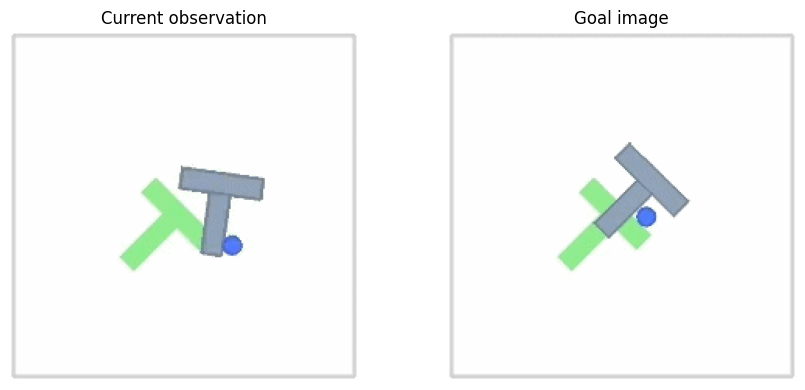

Source GIF size: (224, 448, 3)


In [4]:
# Download and inspect an official PushT example
GIF_URL = "https://le-wm.github.io/static/videos/planning/pusht/pusht_1_half.gif"
gif_path = "/content/lewm_pusht_demo.gif"

urllib.request.urlretrieve(GIF_URL, gif_path)

gif = Image.open(gif_path)
frame0 = next(ImageSequence.Iterator(gif)).convert("RGB")
frame0_np = np.array(frame0)

h, w, _ = frame0_np.shape
mid = w // 2

current_img = frame0_np[:, :mid]
goal_img = frame0_np[:, mid:]

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(current_img)
ax[0].set_title("Current observation")
ax[0].axis("off")

ax[1].imshow(goal_img)
ax[1].set_title("Goal image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("Source GIF size:", frame0_np.shape)

## 5. Preprocess the images and create the 3-frame context

A NumPy RGB image is usually stored as:

```text
(H_img, W_img, C)
```

A PyTorch vision model usually expects:

```text
(C, H_img, W_img)
```

After preprocessing, each image therefore has shape:

```text
(3, 224, 224)
```

where:

- `3` = RGB channels;
- `224` = image height;
- `224` = image width.

LeWM's PushT predictor uses **3 context frames**.

Ideally we would provide three real consecutive observations:

```text
[x_(t-2), x_(t-1), x_t]
```

For this tiny demo we only download one current observation, so we warm-start the model with:

```text
[x_t, x_t, x_t]
```

This repetition is only a convenience for demonstrating the inference code.  
It is not the full evaluation protocol.

In [5]:
#@title Image preprocessing + 3-frame history
IMG_SIZE = 224
HISTORY = int(cfg["predictor"]["num_frames"])
LATENT_DIM = int(cfg["predictor"]["input_dim"])
ACTION_DIM = int(cfg["action_encoder"]["input_dim"])

image_tf = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

current_tensor = image_tf(current_img)
goal_tensor = image_tf(goal_img)

# (history, channels, height, width)
context_pixels = current_tensor.unsqueeze(0).repeat(HISTORY, 1, 1, 1)

print("current_tensor:", tuple(current_tensor.shape))
print("  = (C, H_img, W_img)")
print("  = 3 RGB channels x 224 height x 224 width")

print("\ncontext_pixels:", tuple(context_pixels.shape))
print("  = (HISTORY, C, H_img, W_img)")
print(f"  = {HISTORY} context frames x 3 RGB channels x 224 x 224")

print("\ngoal_tensor:", tuple(goal_tensor.shape))
print("  = one preprocessed RGB goal image")

current_tensor: (3, 224, 224)
  = (C, H_img, W_img)
  = 3 RGB channels x 224 height x 224 width

context_pixels: (3, 3, 224, 224)
  = (HISTORY, C, H_img, W_img)
  = 3 context frames x 3 RGB channels x 224 x 224

goal_tensor: (3, 224, 224)
  = one preprocessed RGB goal image


## 6. First isolate the simplest inference: **one image → one latent vector**

Before doing a full rollout, it helps to see what `model.encode()` does.

The helper below receives:

```text
(T, C, H_img, W_img)
```

and adds a batch dimension:

```text
(B, T, C, H_img, W_img)
```

For one image:

```text
(1, 1, 3, 224, 224)
```

The encoder returns:

```text
(B, T, D)
= (1, 1, 192)
```

So the RGB image becomes one vector with **192 learned features**.

In [6]:
@torch.inference_mode()
def encode_pixels(pixel_sequence):
    # Input:  (T, C, H_img, W_img)
    # Output: (B=1, T, D)
    info = {"pixels": pixel_sequence.unsqueeze(0).to(DEVICE)}
    return model.encode(info)["emb"]

one_current_emb = encode_pixels(current_tensor.unsqueeze(0))
one_goal_emb = encode_pixels(goal_tensor.unsqueeze(0))

print("One current image ->", tuple(one_current_emb.shape))
print("One goal image    ->", tuple(one_goal_emb.shape))

print("\nMeaning of (1, 1, 192):")
print("1 batch x 1 time step x 192 latent features")


One current image -> (1, 1, 192)
One goal image    -> (1, 1, 192)

Meaning of (1, 1, 192):
1 batch x 1 time step x 192 latent features


## 7. Build a few candidate future action sequences

This is the section where the old notebook became unnecessarily confusing.

### Raw PushT action

One raw control is 2-D:

```text
(x, y)
```

### Model-level action feature

Because five raw actions are packed together, LeWM receives:

```text
[x1, y1, x2, y2, x3, y3, x4, y4, x5, y5]
```

which has length 10.

For this lightweight demo, we use **constant hypothetical directions** in normalized model space.

Example:

```text
+x = (0.55, 0.0)
```

is repeated five times:

```text
[0.55, 0.0,
 0.55, 0.0,
 0.55, 0.0,
 0.55, 0.0,
 0.55, 0.0]
```

These are valid numeric inputs for demonstrating the pretrained forward pass.

They are **not** claimed to be exact raw mouse/controller coordinates from the full PushT benchmark.

In [7]:
#@title Candidate actions in normalized model space
HORIZON = 5

# A raw PushT action is 2-D: (x, y).
# The model receives five packed raw actions, so ACTION_DIM = 5 * 2 = 10.
RAW_ACTION_DIM = 2
FRAMESKIP = ACTION_DIM // RAW_ACTION_DIM

candidate_xy = {
    "zero":       (0.00,  0.00),
    "+x":         (0.55,  0.00),
    "-x":         (-0.55, 0.00),
    "+y":         (0.00,  0.55),
    "-y":         (0.00, -0.55),
    "diagonal":   (0.40,  0.40),
}

def action_block(xy, action_dim=ACTION_DIM):
    # Repeat the same illustrative (x, y) action five times:
    # (x, y) -> (x, y, x, y, x, y, x, y, x, y)
    xy = torch.tensor(xy, dtype=torch.float32)
    return xy.repeat(action_dim // 2)

candidate_names = list(candidate_xy)

candidate_actions = torch.stack([
    action_block(candidate_xy[name]).unsqueeze(0).repeat(HORIZON, 1)
    for name in candidate_names
], dim=0)

# Shape = (S, K, A)
# S = number of candidate plans
# K = future horizon
# A = packed action feature dimension
S = len(candidate_names)

print("Candidate action tensor:", tuple(candidate_actions.shape))
print(
    f"= {S} candidate plans x "
    f"{HORIZON} future steps x "
    f"{ACTION_DIM} action values"
)

# Show the exact 10-D vector used by each candidate.
action_table = pd.DataFrame(
    candidate_actions[:, 0, :].numpy(),
    index=candidate_names,
    columns=[f"a{i}" for i in range(ACTION_DIM)],
)

display(action_table)

Candidate action tensor: (6, 5, 10)
= 6 candidate plans x 5 future steps x 10 action values


,a0,a1,a2,a3,a4,a5,a6,a7,a8,a9
zero,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
+x,0.55,0.00,0.55,0.00,0.55,0.00,0.55,0.00,0.55,0.00
-x,-0.55,0.00,-0.55,0.00,-0.55,0.00,-0.55,0.00,-0.55,0.00
+y,0.00,0.55,0.00,0.55,0.00,0.55,0.00,0.55,0.00,0.55
-y,0.00,-0.55,0.00,-0.55,0.00,-0.55,0.00,-0.55,0.00,-0.55
diagonal,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40


## 8. The actual LeWM inference loop

Now we ask the pretrained model to imagine the future.

### Pixel tensor expected by `model.rollout()`

```text
(B, S, HISTORY, C, H_img, W_img)
```

For this notebook:

```text
(1, 6, 3, 3, 224, 224)
```

Read it literally:

```text
1 batch
× 6 candidate plans
× 3 context frames
× 3 RGB channels
× 224 height
× 224 width
```

All candidates start from the same current visual context.  
Only the future actions differ.

### Action tensor

We want 5 future predictions.

The official rollout aligns actions with the history, so we provide:

```text
2 warm-start zero actions
+ 5 candidate actions
= 7 action entries
```

Therefore the action tensor is:

```text
(B, S, 7, A)
= (1, 6, 7, 10)
```

For one candidate, conceptually:

```text
context images : [x_t, x_t, x_t]

actions        : [0,   0,   a0,  a1,  a2,  a3,  a4]

predictions    :           z1,  z2,  z3,  z4,  z5
```

At each future step LeWM:

1. keeps the most recent latent context;
2. embeds the aligned actions;
3. predicts one next latent;
4. appends that predicted latent;
5. uses it again for the next prediction.

That is the autoregressive rollout.

In [8]:
#@title Run the OFFICIAL LeWM autoregressive rollout

# We already defined encode_pixels above:
# (T, C, H_img, W_img) -> (1, T, D)

# Encode the goal once.
goal_emb = encode_pixels(goal_tensor.unsqueeze(0))[:, -1, :]  # (1, D)

S = len(candidate_names)

# ------------------------------------------------------------
# 1) Build the visual context for every candidate plan
# ------------------------------------------------------------
context_for_rollout = (
    context_pixels
    .unsqueeze(0)            # (1, HISTORY, C, H_img, W_img)
    .unsqueeze(1)            # (1, 1, HISTORY, C, H_img, W_img)
    .expand(1, S, -1, -1, -1, -1)
    .contiguous()
    .to(DEVICE)
)

print("context_for_rollout:", tuple(context_for_rollout.shape))
print(
    f"= 1 batch x {S} plans x {HISTORY} context frames x "
    f"3 RGB channels x {IMG_SIZE} x {IMG_SIZE}"
)

# ------------------------------------------------------------
# 2) Build the aligned action sequence
# ------------------------------------------------------------
history_actions = torch.zeros(
    S,
    HISTORY - 1,
    ACTION_DIM,
    dtype=torch.float32,
)

action_sequence = torch.cat(
    [history_actions, candidate_actions],
    dim=1,
).unsqueeze(0).to(DEVICE)

print("\naction_sequence:", tuple(action_sequence.shape))
print(
    f"= 1 batch x {S} plans x "
    f"({HISTORY - 1} warm-start + {HORIZON} future) steps x "
    f"{ACTION_DIM} values"
)

# ------------------------------------------------------------
# 3) Run the pretrained world model
# ------------------------------------------------------------
rollout_info = {"pixels": context_for_rollout}

t0 = time.perf_counter()

rollout_info = model.rollout(
    rollout_info,
    action_sequence,
    history_size=HISTORY,
)

if DEVICE == "cuda":
    torch.cuda.synchronize()

elapsed = time.perf_counter() - t0

predicted_emb = rollout_info["predicted_emb"]

print("\npredicted_emb:", tuple(predicted_emb.shape))
print(f"Official rollout time for {S} candidates: {elapsed * 1000:.1f} ms")

# Expected:
# (B, S, HISTORY + HORIZON, D)
B_out, S_out, T_out, D_out = predicted_emb.shape

print("\nTranslate the output shape:")
print("B =", B_out, "-> batch size")
print("S =", S_out, "-> candidate plans")
print(
    "T =", T_out,
    f"-> {HISTORY} context latent states + {HORIZON} predicted future states"
)
print("D =", D_out, "-> latent features per state")

assert T_out == HISTORY + HORIZON
assert D_out == LATENT_DIM

# Remove the batch dimension because B=1.
all_rollouts = predicted_emb[0]

# Keep only the 5 truly predicted future states.
future_rollouts = all_rollouts[:, HISTORY:, :]

print("\nall_rollouts:", tuple(all_rollouts.shape))
print(
    f"= {S} plans x {HISTORY + HORIZON} total latent states x "
    f"{LATENT_DIM} features"
)

print("\nfuture_rollouts:", tuple(future_rollouts.shape))
print(
    f"= {S} plans x {HORIZON} predicted future states x "
    f"{LATENT_DIM} features"
)

print("\n✓ Official model.rollout() completed successfully")

context_for_rollout: (1, 6, 3, 3, 224, 224)
= 1 batch x 6 plans x 3 context frames x 3 RGB channels x 224 x 224

action_sequence: (1, 6, 7, 10)
= 1 batch x 6 plans x (2 warm-start + 5 future) steps x 10 values

predicted_emb: (1, 6, 8, 192)
Official rollout time for 6 candidates: 254.9 ms

Translate the output shape:
B = 1 -> batch size
S = 6 -> candidate plans
T = 8 -> 3 context latent states + 5 predicted future states
D = 192 -> latent features per state

all_rollouts: (6, 8, 192)
= 6 plans x 8 total latent states x 192 features

future_rollouts: (6, 5, 192)
= 6 plans x 5 predicted future states x 192 features

✓ Official model.rollout() completed successfully


### What just happened?

For each of the 6 candidate plans, the model produced 5 future latent predictions.

Each future state is a vector:

```text
(192,)
```

So:

```text
future_rollouts
=
(6, 5, 192)
```

means:

```text
6 candidate plans
× 5 imagined future states per plan
× 192 latent features per state
```

The number `192` does **not** mean 192 images or 192 classes.

It is simply the dimensionality of LeWM's learned representation space.

> LeWM is asking: **"what representation should come next if I take this action?"**

## 9. Score the candidate futures against the goal

The goal image has already been encoded as:

```text
z_goal : (192,)
```

Each candidate has a final imagined state:

```text
z_hat_final : (192,)
```

For each candidate \(i\):

$
J_i
=
\sum_{d=1}^{192}
\left(
\hat z^{(i)}_{\mathrm{final},d}
-
z_{\mathrm{goal},d}
\right)^2.
$

This produces **one scalar cost per candidate**.

Interpretation:

```text
smaller cost
= final imagined latent is closer to the goal latent
```

This is a planning cost.  
It is not an accuracy percentage or probability.

final_pred: (6, 192)
= 6 candidates x 192 latent features

goal_vec: (192,)
= one goal vector with 192 latent features

scores: (6,)
= one scalar planning cost for each of the 6 candidates


,candidate,latent goal distance ↓
0,-x,103.511292
1,zero,190.997284
2,-y,302.240234
3,+y,340.386322
4,diagonal,352.022003
5,+x,354.788940


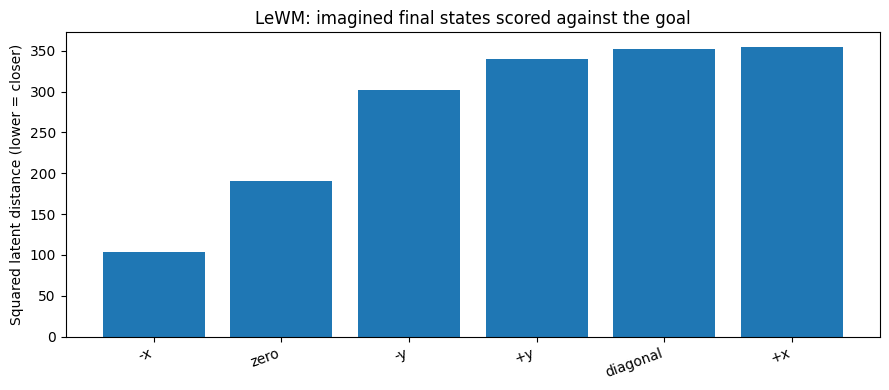

Lowest-cost candidate in this small illustrative set:
-x


In [9]:
#@title Latent goal-distance scores

# Last predicted future state for each candidate:
# future_rollouts = (S, HORIZON, D)
# therefore final_pred = (S, D)
final_pred = future_rollouts[:, -1, :]

# goal_emb = (1, D)
goal_vec = goal_emb[0]

print("final_pred:", tuple(final_pred.shape))
print(f"= {S} candidates x {LATENT_DIM} latent features")

print("\ngoal_vec:", tuple(goal_vec.shape))
print(f"= one goal vector with {LATENT_DIM} latent features")

# Squared Euclidean distance in the full 192-D latent space.
scores = ((final_pred - goal_vec) ** 2).sum(dim=-1)

print("\nscores:", tuple(scores.shape))
print(f"= one scalar planning cost for each of the {S} candidates")

scores_np = scores.detach().cpu().numpy()

result_df = pd.DataFrame({
    "candidate": candidate_names,
    "latent goal distance ↓": scores_np,
}).sort_values(
    "latent goal distance ↓",
    ascending=True,
).reset_index(drop=True)

display(result_df)

plt.figure(figsize=(9, 4))
plt.bar(
    result_df["candidate"],
    result_df["latent goal distance ↓"],
)
plt.ylabel("Squared latent distance (lower = closer)")
plt.xticks(rotation=20, ha="right")
plt.title("LeWM: imagined final states scored against the goal")
plt.tight_layout()
plt.show()

print("Lowest-cost candidate in this small illustrative set:")
print(result_df.iloc[0]["candidate"])

### What does the lowest-cost candidate actually mean?

Suppose `+x` gets the smallest value.

That does **not** prove:

```text
"+x is the correct PushT solution"
```

It only means:

> among the small set of manually proposed action sequences in this notebook,  
> LeWM predicted the final latent produced by `+x` to be closest to the goal latent.

A full MPC/CEM planner would sample or optimize many candidate action sequences, execute an action, observe the environment again, and repeat.

## 10. Optional: visualize the 192-D imagined futures in 2-D

The model actually operates in:

```text
D = 192 dimensions
```

We cannot draw 192 axes, so PCA projects the latent vectors to 2-D **only for visualization**.

Important:

- inference and scoring above still used all 192 dimensions;
- PCA is not part of LeWM planning here;
- do not interpret the PCA axes as physical `x` and `y`;
- only the relative geometry is useful for intuition.

We plot the final real/context latent and the five imagined future latents for each candidate.

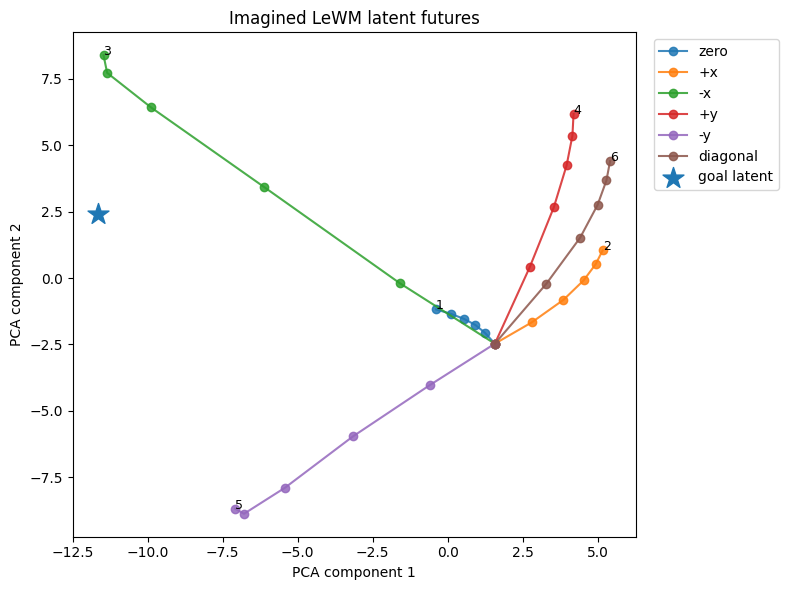

Explained variance by the two PCA dimensions: [0.432 0.289]


In [10]:
#@title PCA visualization of latent rollouts
# Last context latent state + K predicted future latent states.
# Shape per candidate: (1 + HORIZON, D)
traj = all_rollouts[:, HISTORY - 1:, :].detach().cpu()
goal_cpu = goal_emb.detach().cpu()  # (1, D)

S, L, D = traj.shape

X = torch.cat([
    traj.reshape(S * L, D),
    goal_cpu,
], dim=0).numpy()

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

traj2 = X2[:S * L].reshape(S, L, 2)
goal2 = X2[-1]

plt.figure(figsize=(8, 6))

for i, name in enumerate(candidate_names):
    plt.plot(
        traj2[i, :, 0],
        traj2[i, :, 1],
        marker="o",
        label=name,
        alpha=0.85,
    )
    plt.text(
        traj2[i, -1, 0],
        traj2[i, -1, 1],
        str(i + 1),
        fontsize=9,
    )

plt.scatter(
    [goal2[0]],
    [goal2[1]],
    marker="*",
    s=250,
    label="goal latent",
)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Imagined LeWM latent futures")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Explained variance by the two PCA dimensions:",
    np.round(pca.explained_variance_ratio_, 3),
)

## 11. Final takeaway

We performed a real forward inference through the pretrained LeWM PushT model:

$
\boxed{
\text{RGB observation}
\rightarrow
\text{latent state}
\rightarrow
\text{action-conditioned latent rollout}
\rightarrow
\text{goal-distance cost}
}
$

### Shapes worth remembering

```text
one RGB image
(C, H_img, W_img)
= (3, 224, 224)

three-frame context
(HISTORY, C, H_img, W_img)
= (3, 3, 224, 224)

one latent state
(D,)
= (192,)

one packed PushT action
(A,)
= (10,)

candidate action tensor
(S, HORIZON, A)
= (6, 5, 10)

rollout output
(B, S, HISTORY + HORIZON, D)
= (1, 6, 8, 192)
```

### One-sentence interpretation of `(1, 6, 8, 192)`

> **1 batch × 6 candidate plans × (3 context + 5 predicted states) × 192 latent features.**

### Why this matters

LeWM can evaluate possible actions **without decoding future pixels**.

```text
observe
  ↓
encode
  ↓
imagine candidate futures in latent space
  ↓
score against the goal
  ↓
act
  ↓
observe again
```

### Limitation of this 10-minute demo

The notebook uses:

- one current frame repeated three times as a warm-start context;
- a small manually constructed set of action patterns in normalized model space.

Therefore it demonstrates **real pretrained LeWM inference and latent planning mechanics**, but it is not the complete PushT MPC/CEM benchmark.

---

### References

- LeWM repository: https://github.com/lucas-maes/le-wm
- LeWM project page: https://le-wm.github.io/
- Pretrained PushT checkpoint: https://huggingface.co/quentinll/lewm-pusht